In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 54.1 MB/s eta 0:00:00:00:0100:01


In [4]:
import matplotlib.pyplot as plt
import rasterio

def drawdata(linkimage):
    # Mở file ảnh ví dụ
    file_path = linkimage
    with rasterio.open(file_path) as src:
        img = src.read(1)  # đọc band đầu tiên

    plt.figure(figsize=(8, 6))
    plt.imshow(img, cmap='jet')
    plt.title('Ảnh mẫu từ dataset')
    plt.colorbar(label='Giá trị pixel')
    plt.show()

In [5]:
import os
import numpy as np
import rasterio
from scipy.ndimage import generic_filter, binary_dilation

import numpy as np
from scipy import ndimage
from skimage.morphology import binary_dilation, disk
from scipy.ndimage import binary_fill_holes

def fill_nan_morphological(arr, radius=3, threshold=0.5):
    arr_copy = arr.copy()
    nan_mask = np.isnan(arr_copy)
    
    # Create valid mask (non-NaN pixels)
    valid_mask = ~nan_mask
    
    # Create rain mask only where we have valid data
    rain_mask = np.zeros_like(arr, dtype=bool)
    rain_mask[valid_mask] = (arr[valid_mask] >= threshold)
    
    # Dilate the rain mask
    rain_mask_dilated = binary_dilation(rain_mask, disk(radius))
    
    # Fill holes in the dilated rain mask
    rain_filled = binary_fill_holes(rain_mask_dilated)
    
    # Only fill NaN in areas that are likely rain
    fill_mask = nan_mask & rain_filled
    
    # Create a function to safely calculate nanmean
    def safe_nanmean(x):
        x = x[~np.isnan(x)]
        return np.mean(x) if len(x) > 0 else 0.0
    
    # Apply the filter only to areas we want to fill
    interpolated = ndimage.generic_filter(
        arr_copy,
        safe_nanmean,
        size=3,
        mode='nearest'
    )
    
    # Fill only the selected NaN pixels
    arr_copy[fill_mask] = interpolated[fill_mask]
    
    # Set remaining NaN pixels to 0.0
    arr_copy[np.isnan(arr_copy)] = 0.0
    
    return arr_copy


def fill_nan_with_gaussian_masked(arr, sigma=2, threshold=0.5):
    nan_mask = np.isnan(arr)
    
    # Create rain mask only where we have valid data
    valid_mask = ~nan_mask
    rain_mask = np.zeros_like(arr, dtype=bool)
    rain_mask[valid_mask] = (arr[valid_mask] >= threshold)
    
    dilated_mask = ndimage.binary_dilation(rain_mask, iterations=5)
    
    # Only fill NaN in areas near rain
    fill_mask = nan_mask & dilated_mask
    
    # Temporarily fill NaN with 0 for filtering
    filled_zeros = np.where(nan_mask, 0.0, arr)
    weight = (~nan_mask).astype(float)
    
    # Apply Gaussian filter
    smooth_data = ndimage.gaussian_filter(filled_zeros, sigma=sigma)
    smooth_weight = ndimage.gaussian_filter(weight, sigma=sigma)
    
    # Avoid division by zero
    smooth_weight = np.where(smooth_weight == 0, np.nan, smooth_weight)
    filled = np.divide(smooth_data, smooth_weight, where=~np.isnan(smooth_weight))
    
    # Only update pixels we want to fill
    arr_filled = arr.copy()
    arr_filled[fill_mask] = np.where(fill_mask, filled, arr_filled)[fill_mask]
    
    # Set remaining NaN to 0.0
    arr_filled[np.isnan(arr_filled)] = 0.0
    
    return arr_filled



def read_and_fill_radar_tif(file_path, method='gaussian'):
    with rasterio.open(file_path) as src:
        arr = src.read(1).astype(np.float32)
        nodata_val = src.nodata

        arr[arr == nodata_val] = np.nan
        arr[arr == -9999] = np.nan
        arr[arr == -np.inf] = np.nan

        profile = src.profile

    if method == 'gaussian':
        arr = fill_nan_with_gaussian_masked(arr, sigma=2)
    elif method == 'morph':
        arr = fill_nan_morphological(arr, radius = 4)
    else:
        raise ValueError(f"Unknown method: {method}")

    return arr, profile



def fill_all_radar_images(root_path, save_path):
    os.makedirs(save_path, exist_ok=True)

    for year in os.listdir(root_path):
        for month in os.listdir(os.path.join(root_path, year)):
            for day in os.listdir(os.path.join(root_path, year, month)):
                src_dir = os.path.join(root_path, year, month, day)
                dst_dir = os.path.join(save_path, year, month, day)
                os.makedirs(dst_dir, exist_ok=True)

                print(f"🛠 Đang xử lý: {year}/{month}/{day}")

                for hour_file in os.listdir(src_dir):
                    if hour_file.endswith(".tif"):
                        src_file = os.path.join(src_dir, hour_file)
                        dst_file = os.path.join(dst_dir, hour_file)

                        try:
                            arr_filled, profile = read_and_fill_radar_tif(src_file)
                            with rasterio.open(dst_file, 'w', **profile) as dst:
                                dst.write(arr_filled, 1)
                        except Exception as e:
                            print(f"Lỗi với {src_file}: {e}")


In [6]:
import os
import glob
import rasterio

def process_radar_folder(input_folder, output_folder, method='gaussian'):
    # Tạo thư mục đầu ra nếu chưa tồn tại
    os.makedirs(output_folder, exist_ok=True)
    
    # Tìm tất cả file .tif trong thư mục đầu vào
    tif_files = glob.glob(os.path.join(input_folder, "*.tif"))
    
    for input_path in tif_files:
        # Tạo tên file đầu ra
        filename = os.path.basename(input_path)
        output_filename = filename.replace(".tif", "_filled.tif")
        output_path = os.path.join(output_folder, output_filename)
        
        # Xử lý và ghi file
        arr_filled, profile = read_and_fill_radar_tif(input_path, method)
        
        with rasterio.open(output_path, 'w', **profile) as dst:
            dst.write(arr_filled, 1)
        print(f"Processed: {filename} -> {output_filename}")

# Thông số đầu vào
input_folder = "/kaggle/input/data-rain-ai/DATA_SV/Precipitation/Radar/2020/10/01/"
output_folder = "/kaggle/working/radar/"

# Chạy quá trình xử lý
process_radar_folder(input_folder, output_folder, 'gaussian')

Processed: Radar_20201001110000.tif -> Radar_20201001110000_filled.tif
Processed: Radar_20201001080000.tif -> Radar_20201001080000_filled.tif
Processed: Radar_20201001030000.tif -> Radar_20201001030000_filled.tif
Processed: Radar_20201001060000.tif -> Radar_20201001060000_filled.tif
Processed: Radar_20201001190000.tif -> Radar_20201001190000_filled.tif
Processed: Radar_20201001200000.tif -> Radar_20201001200000_filled.tif
Processed: Radar_20201001100000.tif -> Radar_20201001100000_filled.tif
Processed: Radar_20201001160000.tif -> Radar_20201001160000_filled.tif
Processed: Radar_20201001000000.tif -> Radar_20201001000000_filled.tif
Processed: Radar_20201001180000.tif -> Radar_20201001180000_filled.tif
Processed: Radar_20201001210000.tif -> Radar_20201001210000_filled.tif
Processed: Radar_20201001220000.tif -> Radar_20201001220000_filled.tif
Processed: Radar_20201001150000.tif -> Radar_20201001150000_filled.tif
Processed: Radar_20201001020000.tif -> Radar_20201001020000_filled.tif
Proces

/kaggle/working/radar/Radar_20201001010000_filled.tif


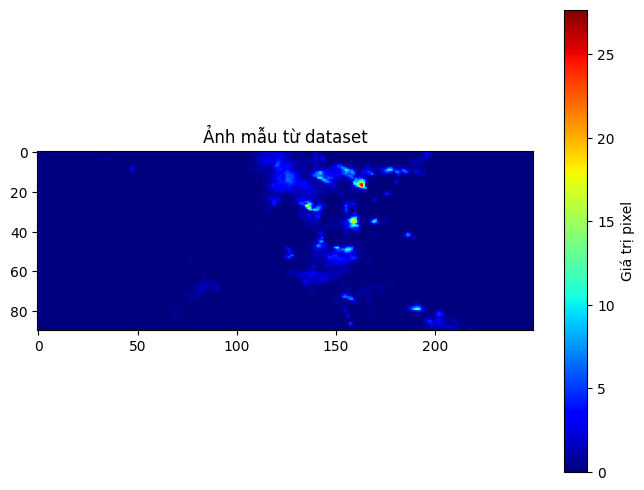

/kaggle/working/radar/Radar_20201001130000_filled.tif


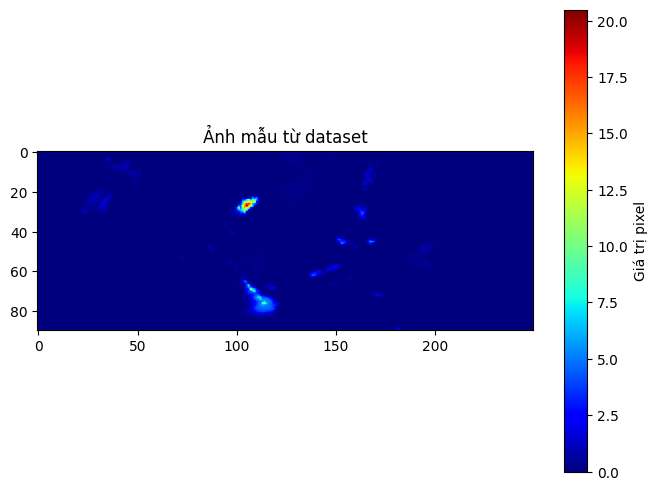

/kaggle/working/radar/Radar_20201001050000_filled.tif


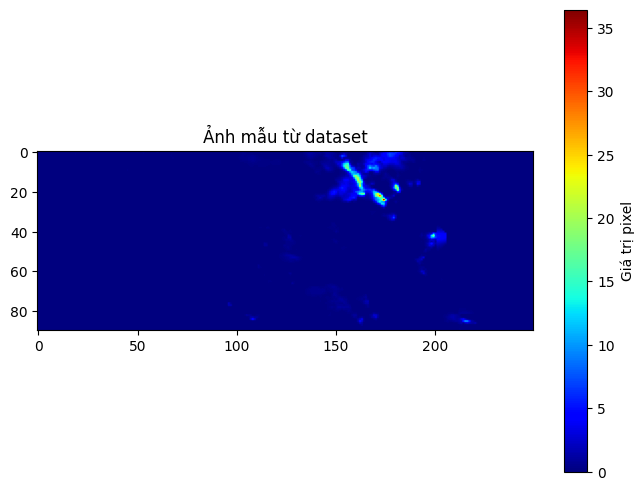

/kaggle/working/radar/Radar_20201001110000_filled.tif


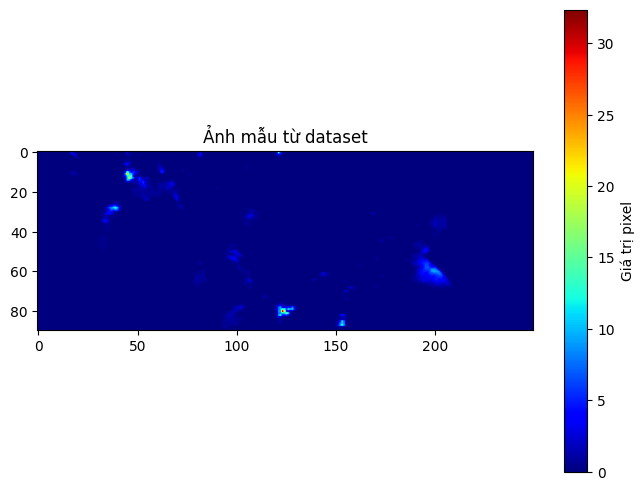

/kaggle/working/radar/Radar_20201001000000_filled.tif


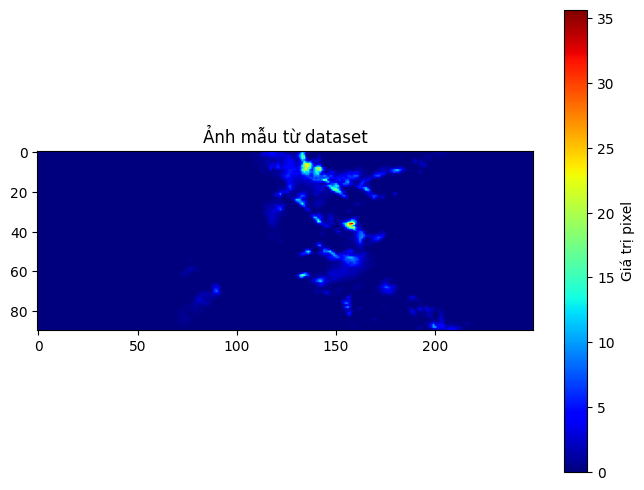

/kaggle/working/radar/Radar_20201001070000_filled.tif


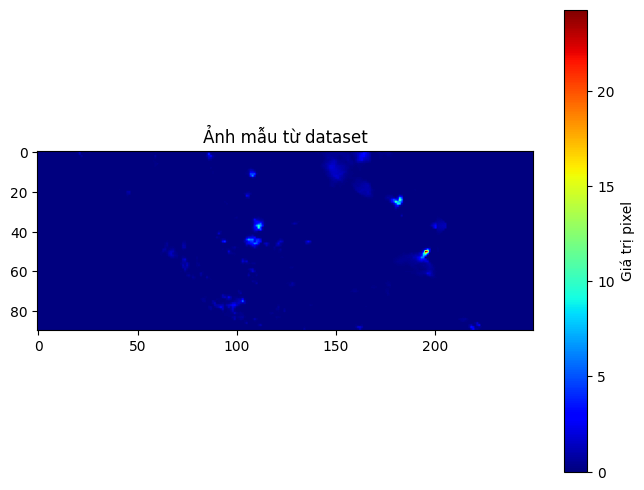

/kaggle/working/radar/Radar_20201001090000_filled.tif


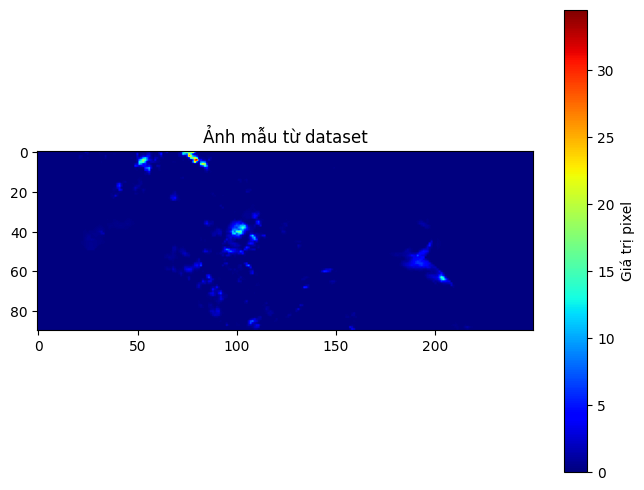

/kaggle/working/radar/Radar_20201001230000_filled.tif


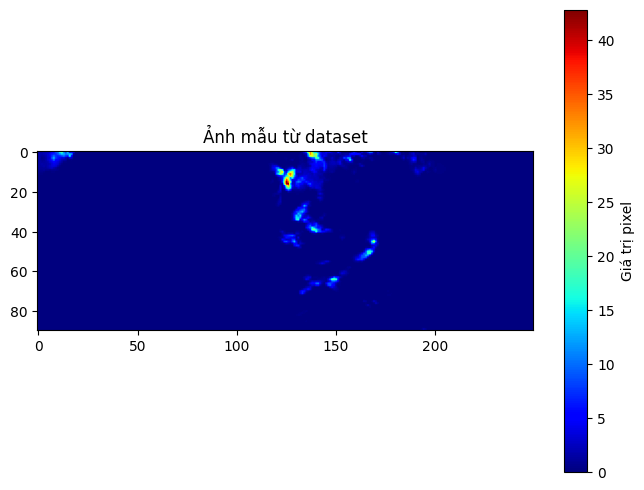

/kaggle/working/radar/Radar_20201001080000_filled.tif


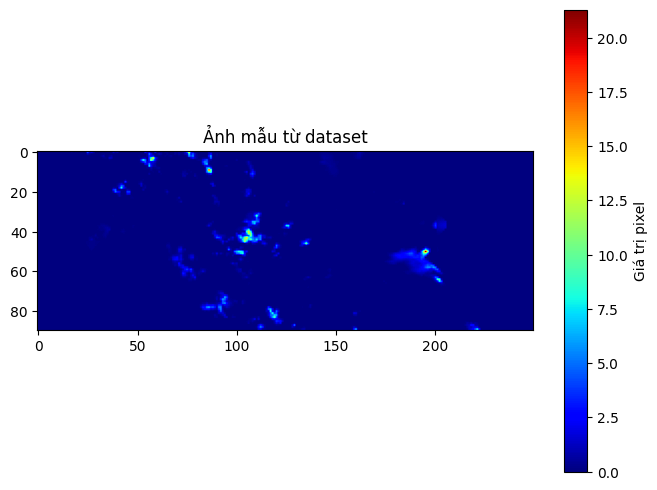

/kaggle/working/radar/Radar_20201001030000_filled.tif


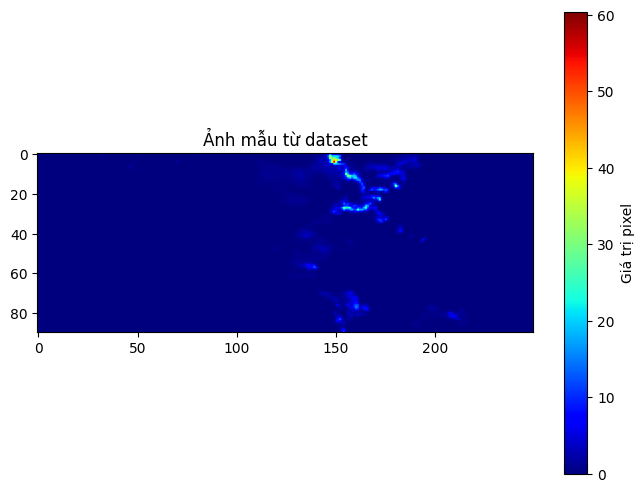

/kaggle/working/radar/Radar_20201001150000_filled.tif


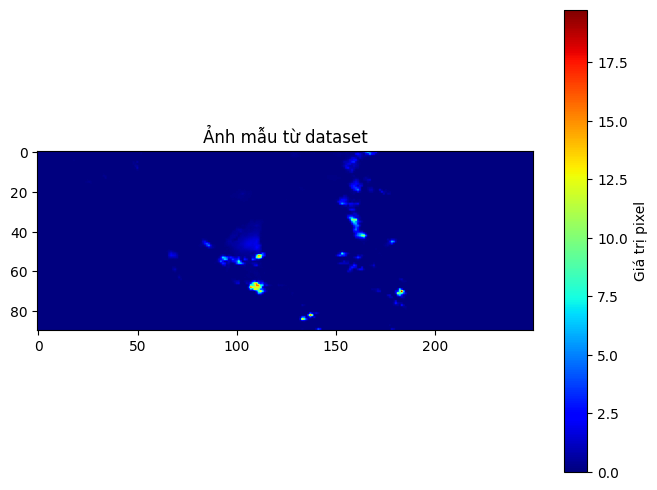

/kaggle/working/radar/Radar_20201001220000_filled.tif


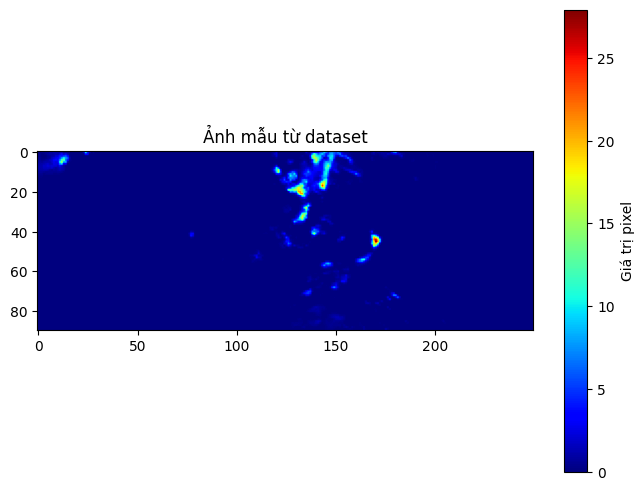

/kaggle/working/radar/Radar_20201001190000_filled.tif


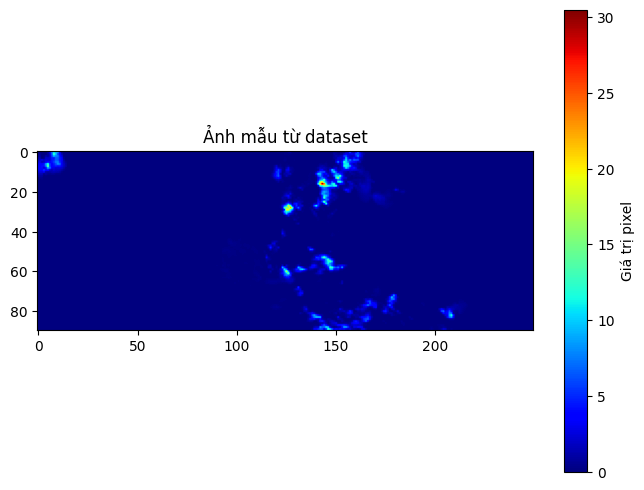

/kaggle/working/radar/Radar_20201001060000_filled.tif


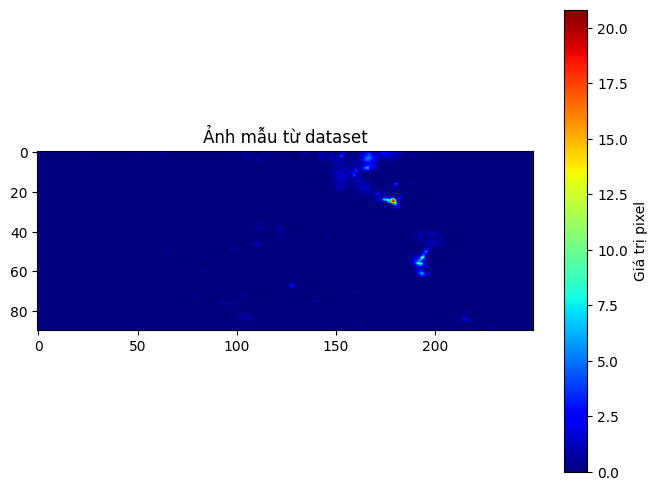

/kaggle/working/radar/Radar_20201001120000_filled.tif


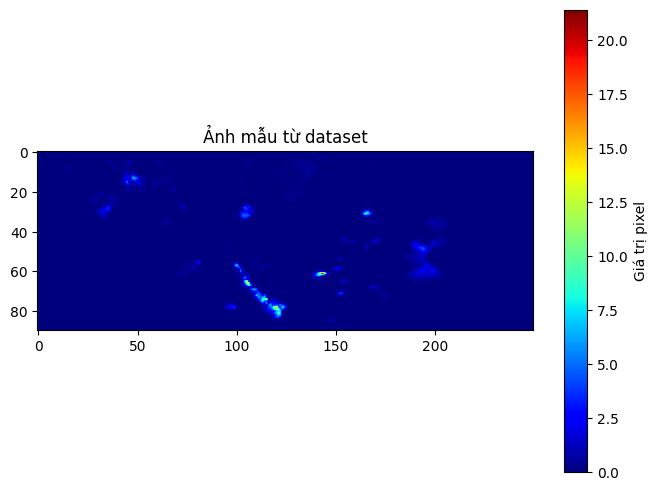

/kaggle/working/radar/Radar_20201001040000_filled.tif


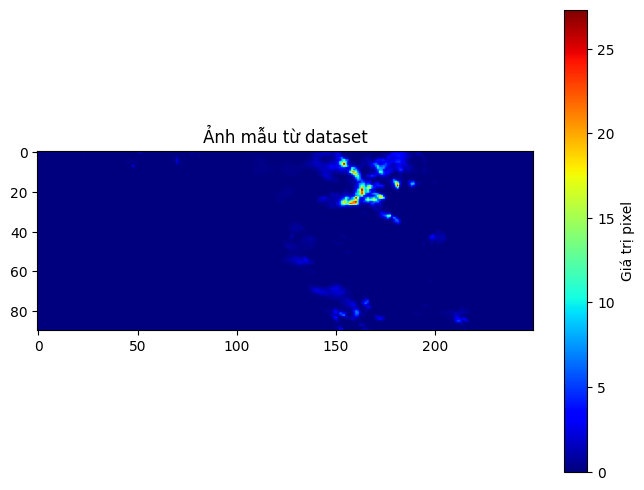

/kaggle/working/radar/Radar_20201001180000_filled.tif


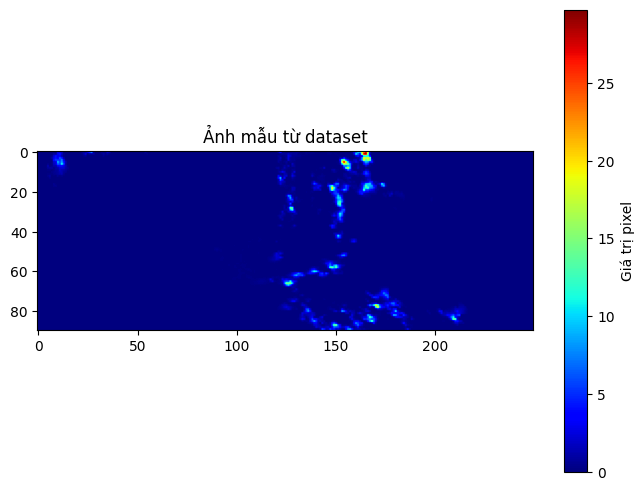

/kaggle/working/radar/Radar_20201001140000_filled.tif


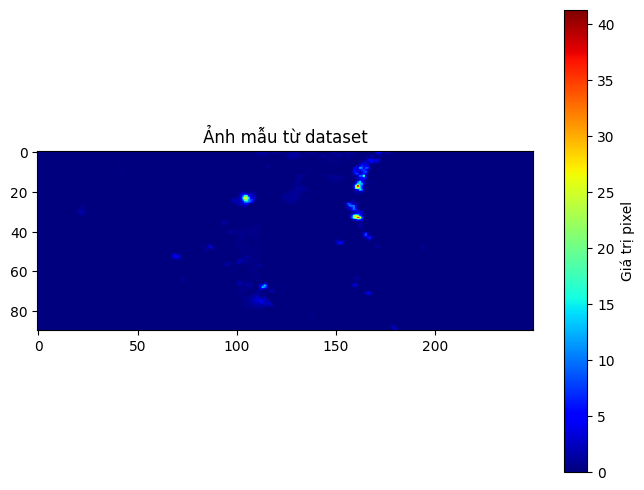

/kaggle/working/radar/Radar_20201001160000_filled.tif


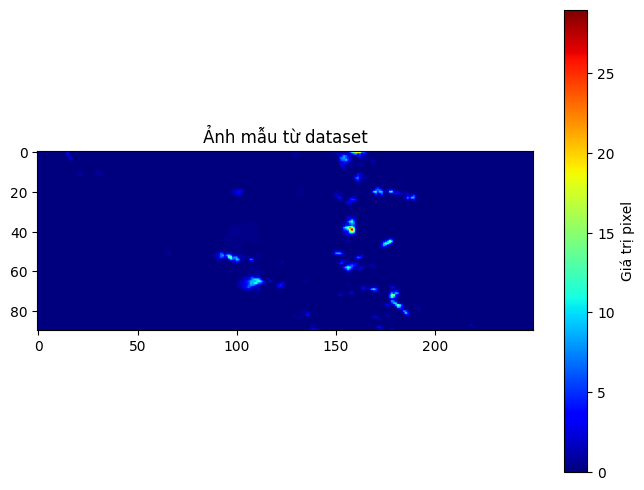

/kaggle/working/radar/Radar_20201001020000_filled.tif


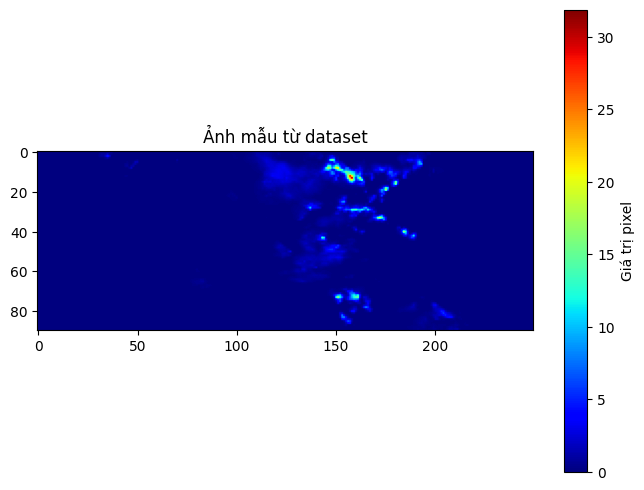

/kaggle/working/radar/Radar_20201001210000_filled.tif


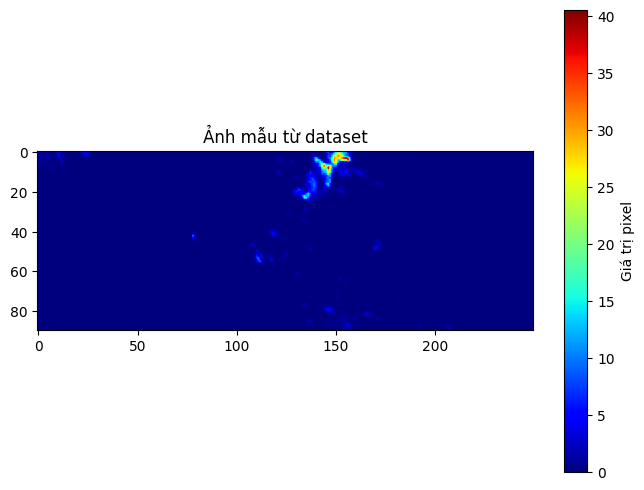

/kaggle/working/radar/Radar_20201001170000_filled.tif


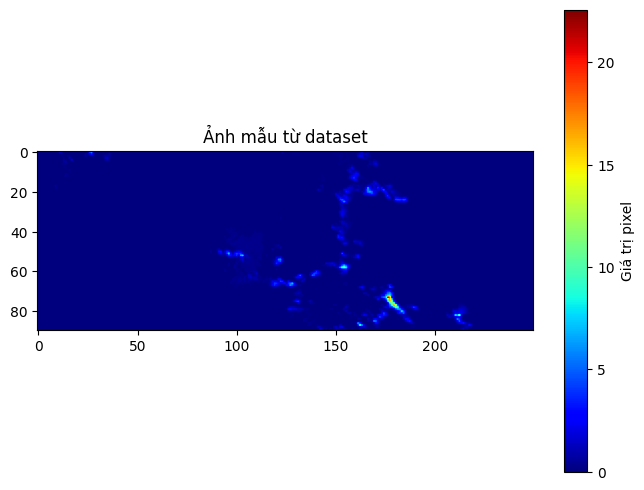

/kaggle/working/radar/Radar_20201001200000_filled.tif


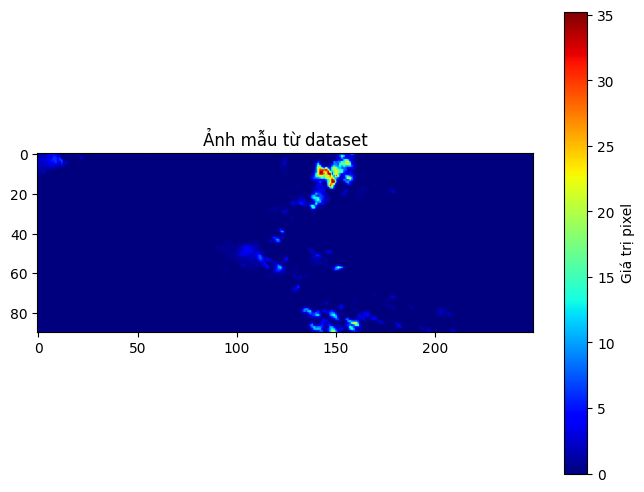

/kaggle/working/radar/Radar_20201001100000_filled.tif


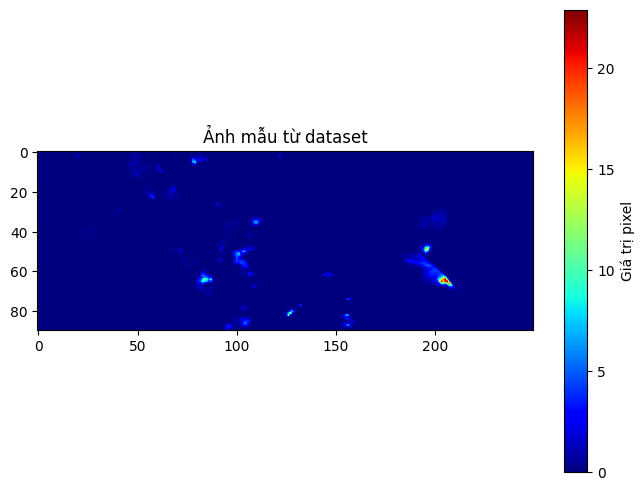

In [7]:
import os

folder_path = "/kaggle/working/radar/"  # Thay bằng đường dẫn thư mục của bạn

for dirname, _, filenames in os.walk(folder_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        t = dirname + filename
        drawdata(t)

In [8]:
# fill_all_radar_images("/kaggle/input/data-rain-ai/DATA_SV/Precipitation/Radar", '/kaggle/working/processed/Radar')

In [9]:
# from IPython.display import HTML
# import base64
# from IPython.display import FileLink

# # Nén thư mục
# !zip -r /kaggle/working/processed.zip /kaggle/working/processed/Radar

# # Tạo link download
# FileLink("/kaggle/working/processed.zip")

# # Tạo link download trực tiếp
# zip_path = "/kaggle/working/processed.zip"
# with open(zip_path, "rb") as f:
#     b64 = base64.b64encode(f.read()).decode()
    
# HTML(f'<a href="data:application/zip;base64,{b64}" download="radar_data.zip">Download ZIP</a>')

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001110000.tif


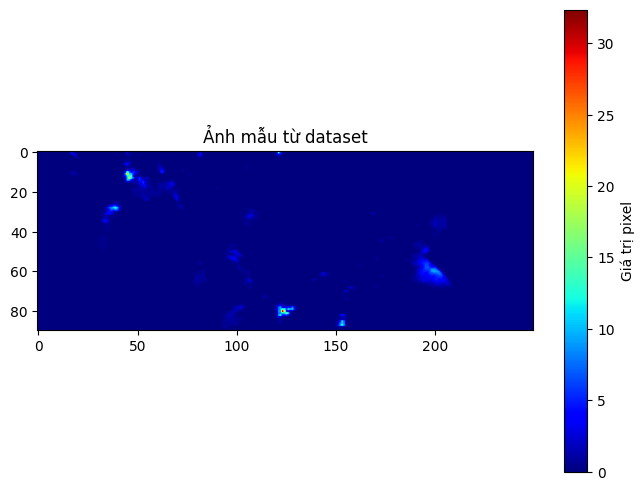

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001080000.tif


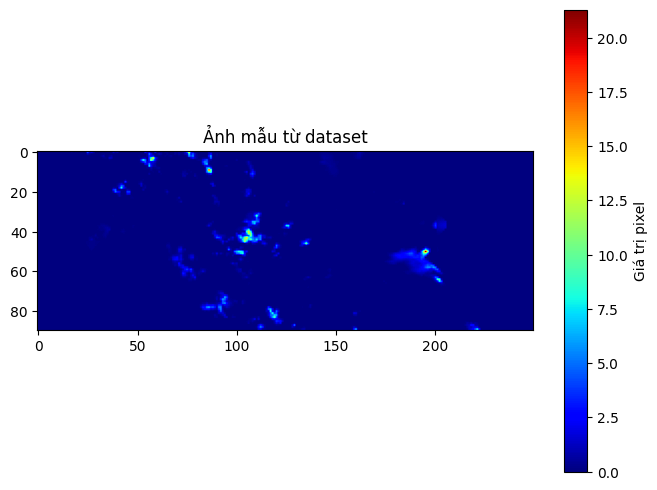

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001030000.tif


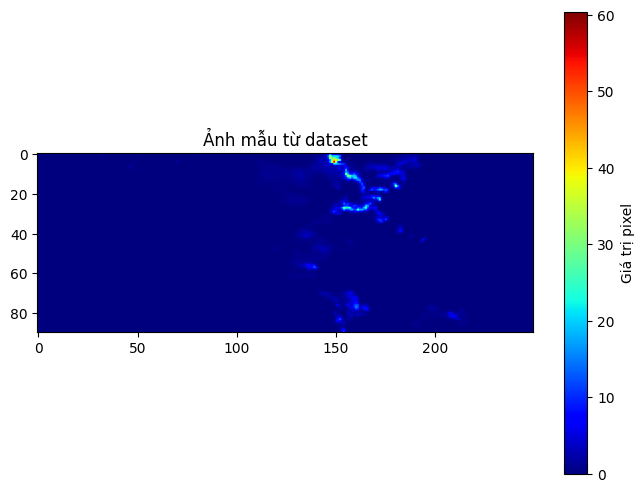

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001060000.tif


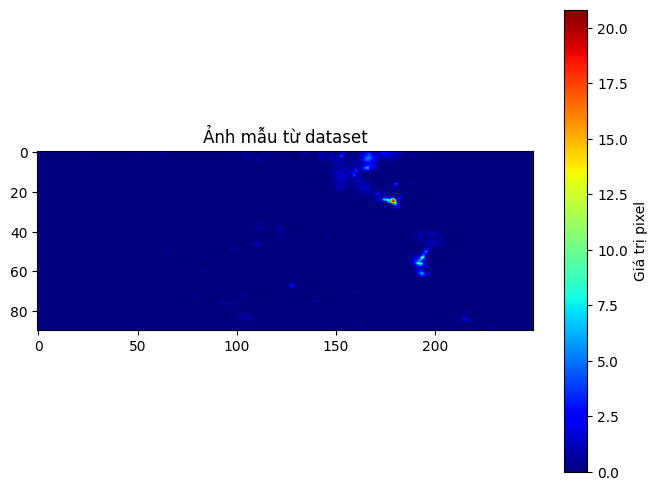

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001190000.tif


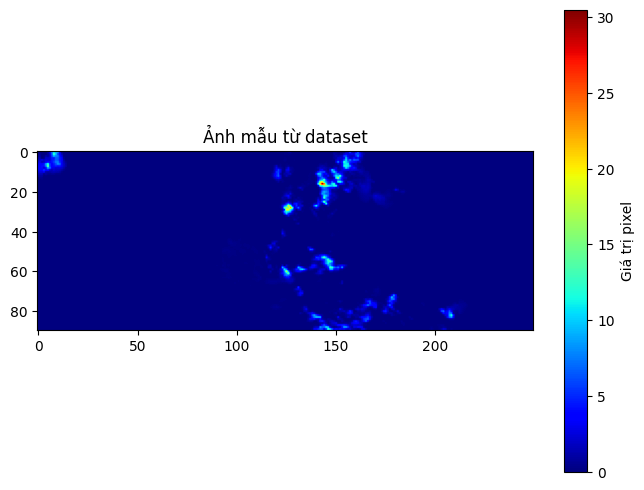

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001200000.tif


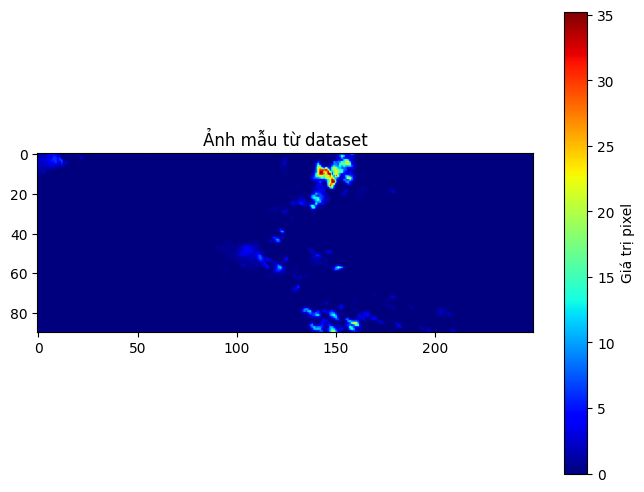

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001100000.tif


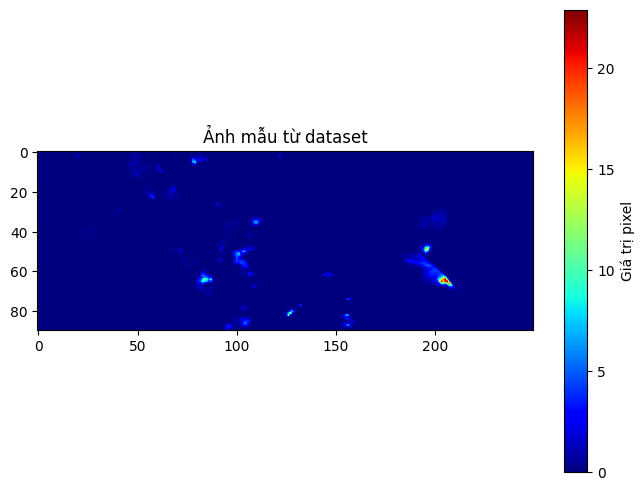

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001160000.tif


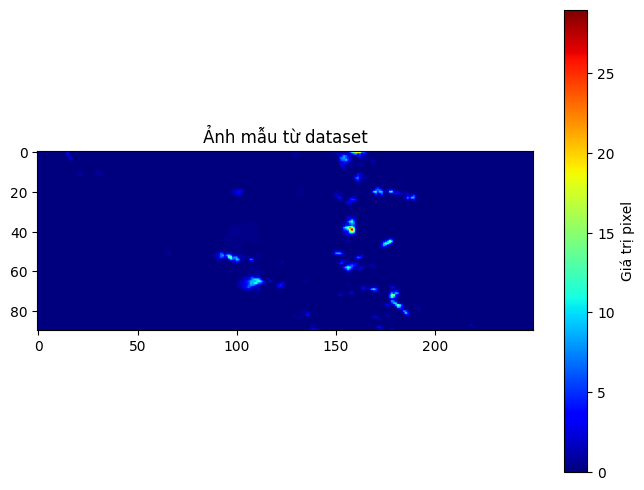

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001000000.tif


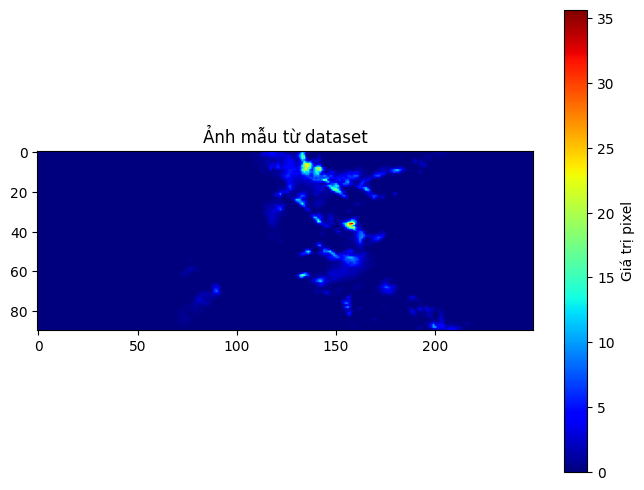

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001180000.tif


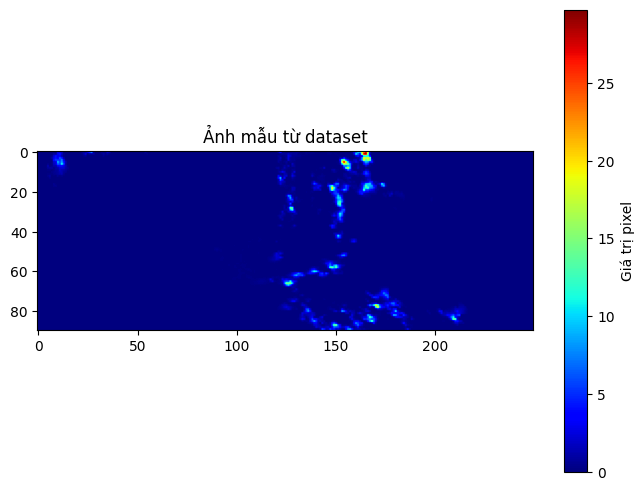

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001210000.tif


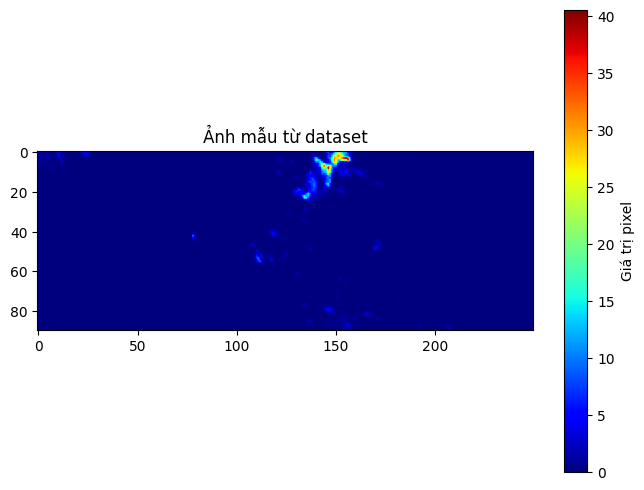

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001220000.tif


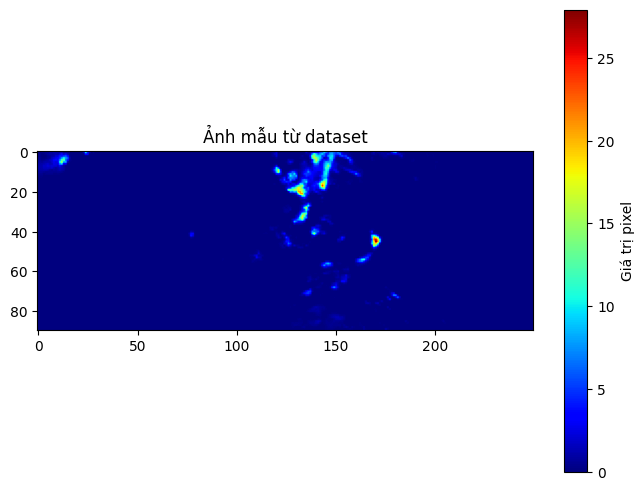

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001150000.tif


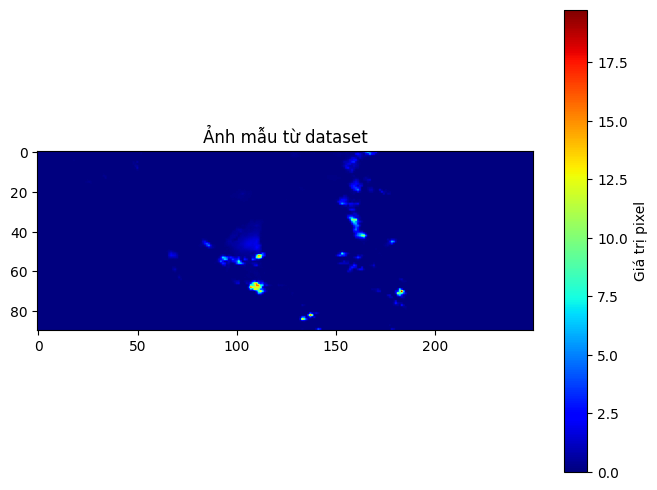

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001020000.tif


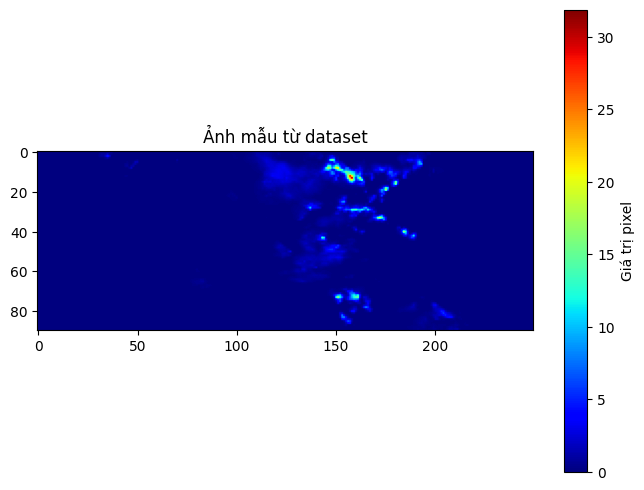

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001230000.tif


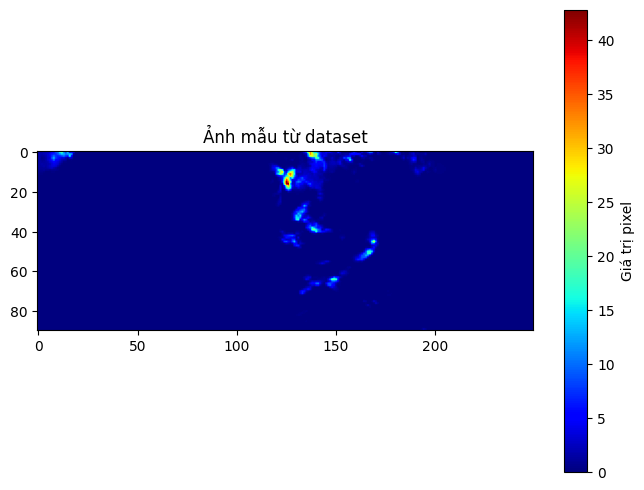

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001130000.tif


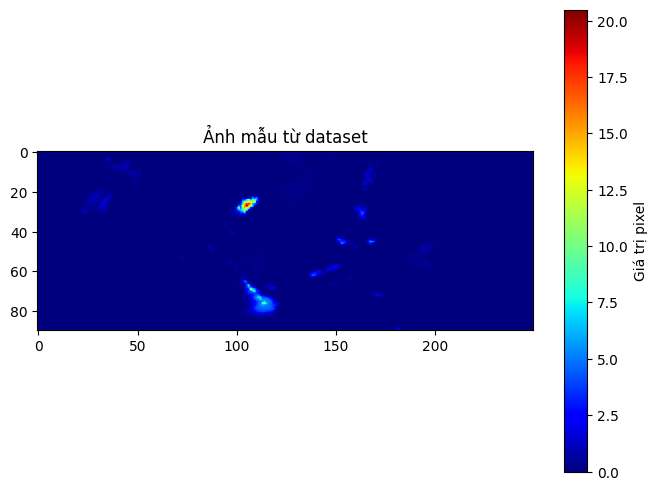

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001010000.tif


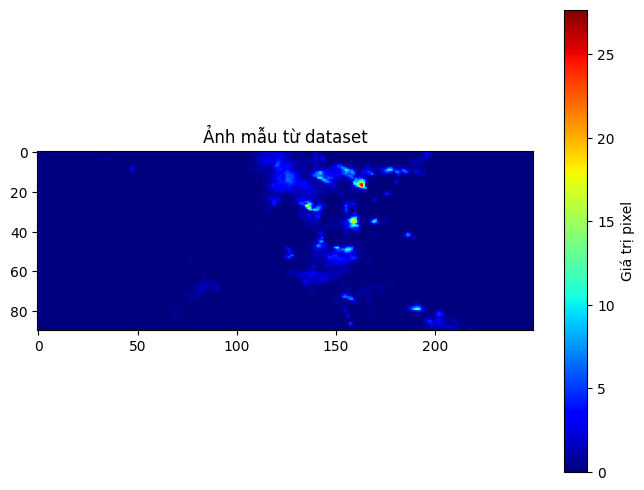

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001050000.tif


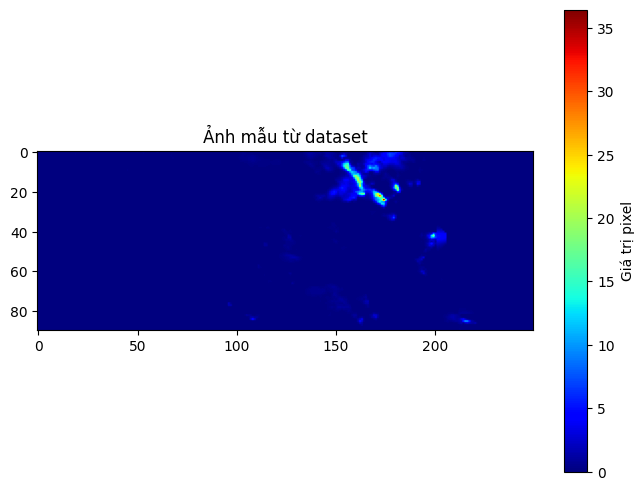

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001170000.tif


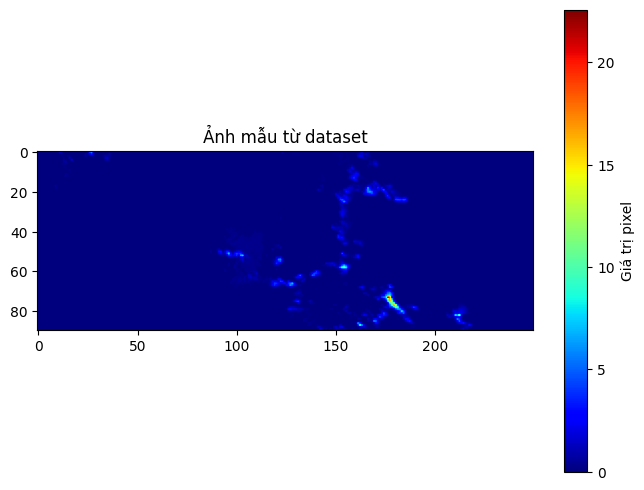

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001120000.tif


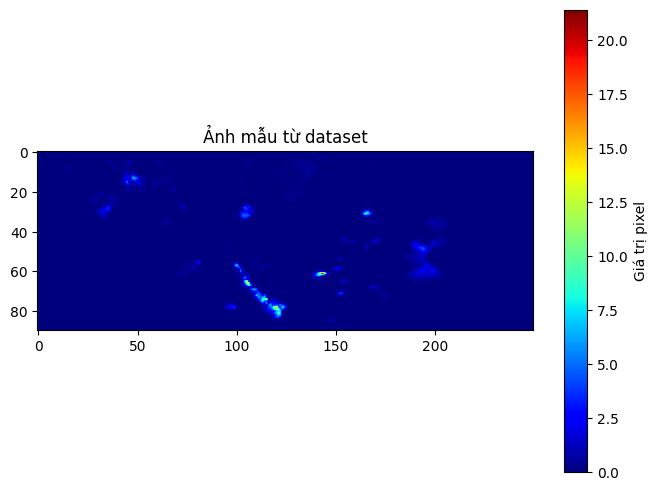

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001070000.tif


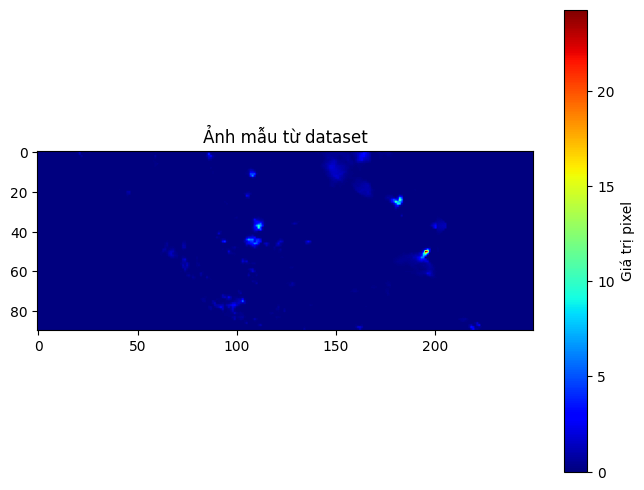

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001090000.tif


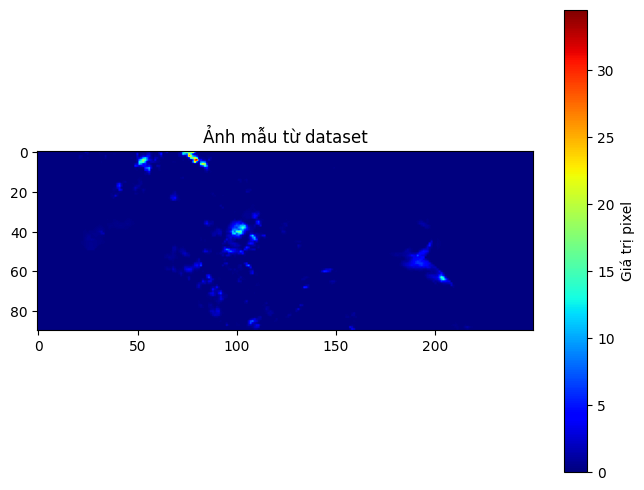

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001140000.tif


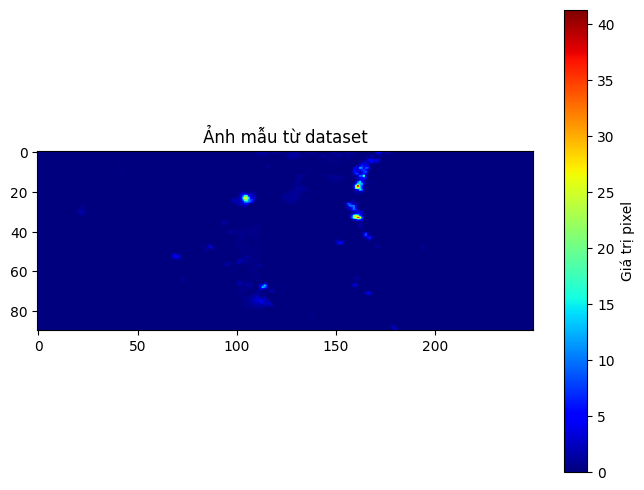

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001040000.tif


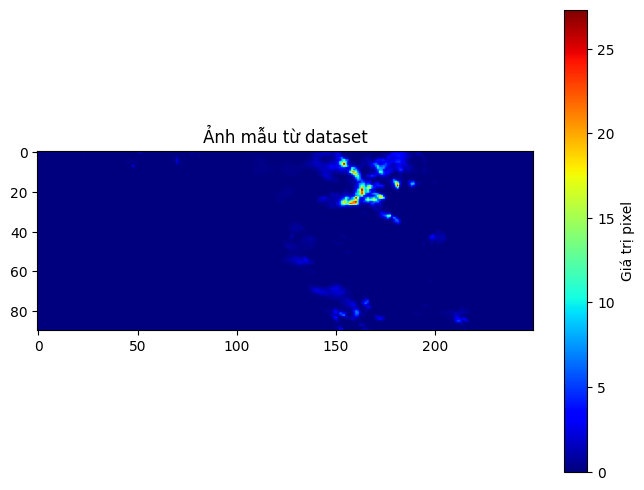

In [10]:
import os

folder_path = "/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/"  # Thay bằng đường dẫn thư mục của bạn

for dirname, _, filenames in os.walk(folder_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        t = dirname + filename
        drawdata(t)

In [11]:
import numpy as np

def kalman_filter_1d_series(data_series, Q=1e-3, R=1e-1):
    """
    Áp dụng bộ lọc Kalman cho một chuỗi dữ liệu 1D (dọc theo trục thời gian tại 1 pixel).
    """
    n = len(data_series)
    x_est = np.zeros(n)
    P = np.zeros(n)

    # Khởi tạo
    x_est[0] = data_series[0]
    P[0] = 1.0

    for k in range(1, n):
        # Dự đoán
        x_pred = x_est[k-1]
        P_pred = P[k-1] + Q

        # Cập nhật
        K = P_pred / (P_pred + R)
        x_est[k] = x_pred + K * (data_series[k] - x_pred)
        P[k] = (1 - K) * P_pred

    return x_est

def apply_kalman_to_stack(image_stack, Q=1e-3, R=1e-1):
    """
    Áp dụng bộ lọc Kalman cho từng pixel theo chuỗi thời gian (trục 0).
    image_stack: (T, H, W) với T là số thời điểm
    """
    T, H, W = image_stack.shape
    filtered_stack = np.zeros_like(image_stack)

    for i in range(H):
        for j in range(W):
            pixel_series = image_stack[:, i, j]
            filtered_stack[:, i, j] = kalman_filter_1d_series(pixel_series, Q, R)

    return filtered_stack


In [12]:
import glob
import rasterio

def load_filled_images_as_stack(folder_path):
    tif_files = sorted(glob.glob(os.path.join(folder_path, "*.tif")))
    image_stack = []

    for file in tif_files:
        with rasterio.open(file) as src:
            image_stack.append(src.read(1).astype(np.float32))

    return np.stack(image_stack), tif_files

# Load ảnh
image_stack, filenames = load_filled_images_as_stack("/kaggle/working/radar/")

# Apply Kalman
filtered_stack = apply_kalman_to_stack(image_stack)

# Save lại
def save_stack_to_tif(stack, template_files, save_folder):
    os.makedirs(save_folder, exist_ok=True)
    for i in range(stack.shape[0]):
        with rasterio.open(template_files[i]) as src:
            profile = src.profile
        out_path = os.path.join(save_folder, os.path.basename(template_files[i]).replace(".tif", "_kalman.tif"))
        with rasterio.open(out_path, 'w', **profile) as dst:
            dst.write(stack[i], 1)

save_stack_to_tif(filtered_stack, filenames, "/kaggle/working/processed_kalman")


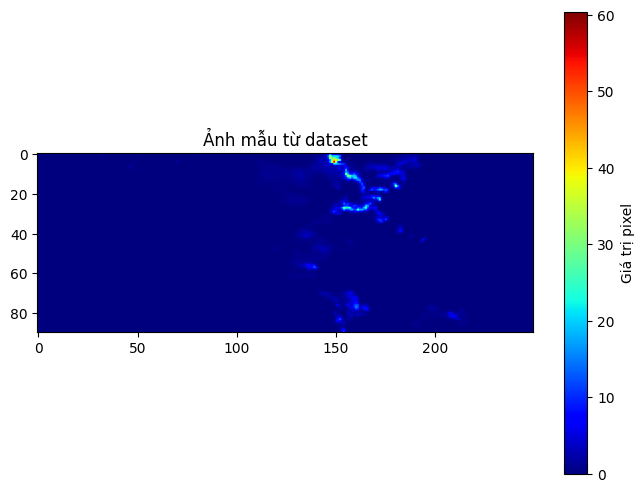

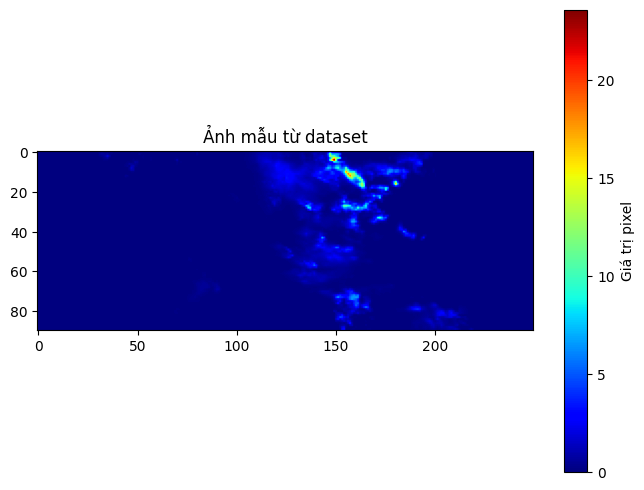

In [13]:
drawdata("/kaggle/working/radar/Radar_20201001030000_filled.tif")
drawdata("/kaggle/working/processed_kalman/Radar_20201001030000_filled_kalman.tif")

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


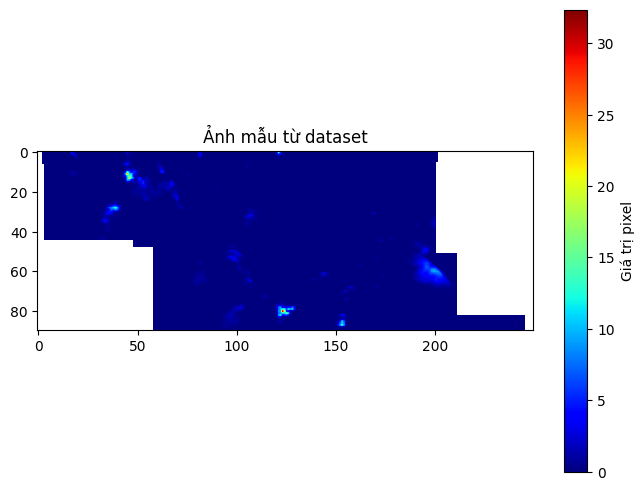

In [14]:
drawdata("/kaggle/input/data-rain-ai/DATA_SV/Precipitation/Radar/2020/10/01/Radar_20201001110000.tif")

In [15]:
import os
import glob
import rasterio

def process_radar_folder(input_folder, output_folder, method='morph'):
    # Tạo thư mục đầu ra nếu chưa tồn tại
    os.makedirs(output_folder, exist_ok=True)
    
    # Tìm tất cả file .tif trong thư mục đầu vào
    tif_files = glob.glob(os.path.join(input_folder, "*.tif"))
    
    for input_path in tif_files:
        # Tạo tên file đầu ra
        filename = os.path.basename(input_path)
        output_filename = filename.replace(".tif", "_filled.tif")
        output_path = os.path.join(output_folder, output_filename)
        
        # Xử lý và ghi file
        arr_filled, profile = read_and_fill_radar_tif(input_path, method)
        
        with rasterio.open(output_path, 'w', **profile) as dst:
            dst.write(arr_filled, 1)
        print(f"Processed: {filename} -> {output_filename}")

# Thông số đầu vào
input_folder = "/kaggle/input/data-rain-ai/DATA_SV/Precipitation/Radar/2020/10/01/"
output_folder = "/kaggle/working/radar/"

# Chạy quá trình xử lý
process_radar_folder(input_folder, output_folder, 'morph')

Processed: Radar_20201001110000.tif -> Radar_20201001110000_filled.tif
Processed: Radar_20201001080000.tif -> Radar_20201001080000_filled.tif
Processed: Radar_20201001030000.tif -> Radar_20201001030000_filled.tif
Processed: Radar_20201001060000.tif -> Radar_20201001060000_filled.tif
Processed: Radar_20201001190000.tif -> Radar_20201001190000_filled.tif
Processed: Radar_20201001200000.tif -> Radar_20201001200000_filled.tif
Processed: Radar_20201001100000.tif -> Radar_20201001100000_filled.tif
Processed: Radar_20201001160000.tif -> Radar_20201001160000_filled.tif
Processed: Radar_20201001000000.tif -> Radar_20201001000000_filled.tif
Processed: Radar_20201001180000.tif -> Radar_20201001180000_filled.tif
Processed: Radar_20201001210000.tif -> Radar_20201001210000_filled.tif
Processed: Radar_20201001220000.tif -> Radar_20201001220000_filled.tif
Processed: Radar_20201001150000.tif -> Radar_20201001150000_filled.tif
Processed: Radar_20201001020000.tif -> Radar_20201001020000_filled.tif
Proces

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001110000.tif


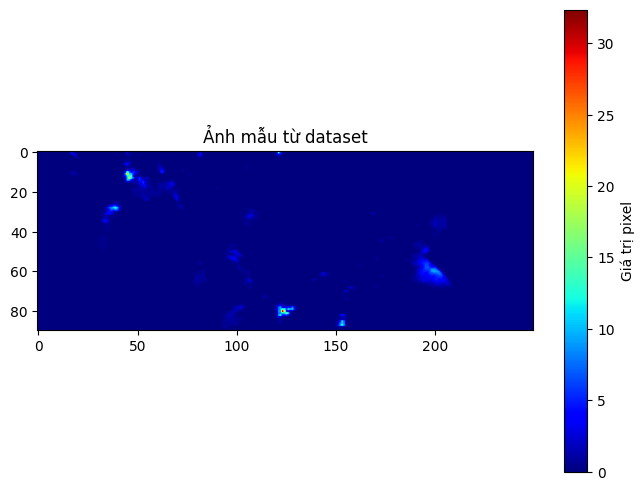

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001080000.tif


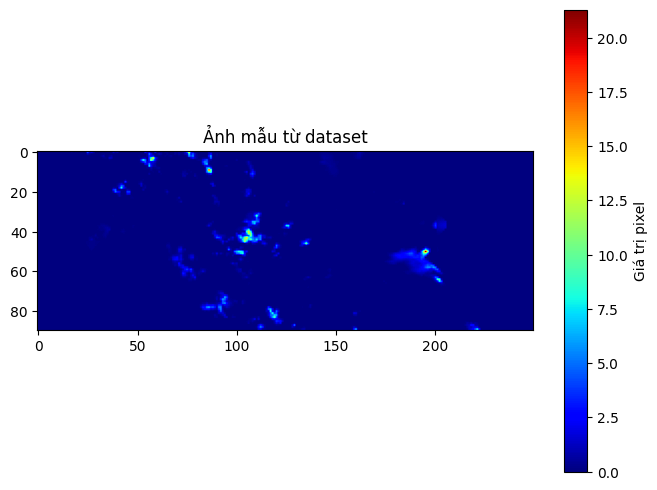

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001030000.tif


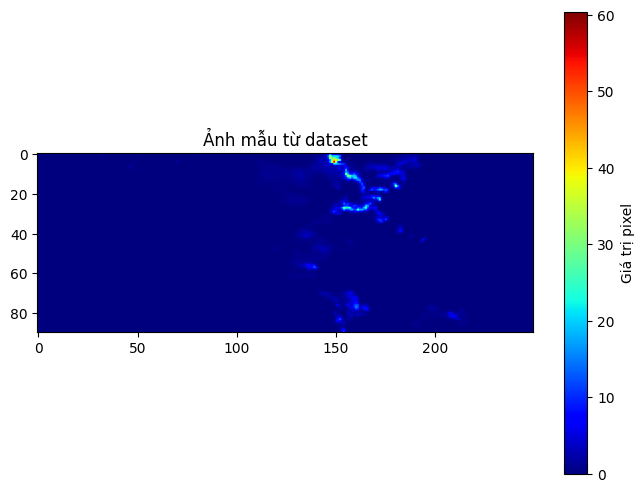

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001060000.tif


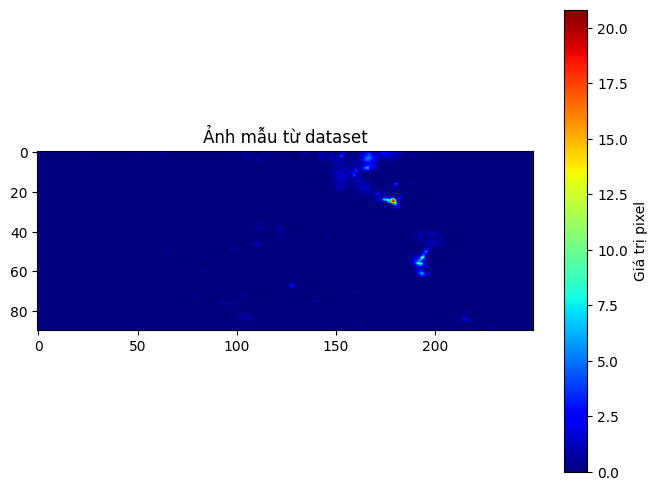

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001190000.tif


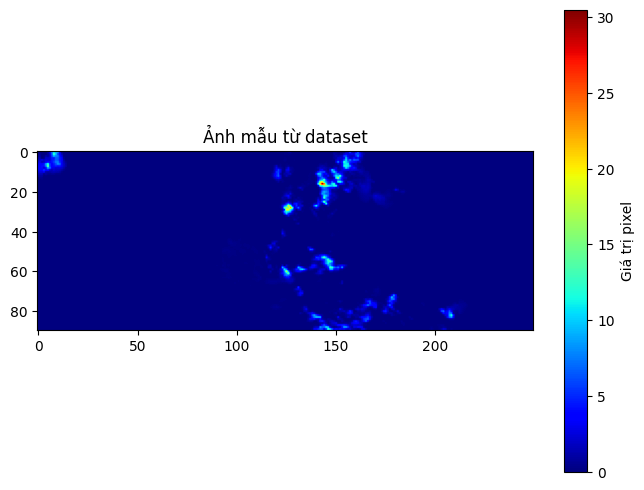

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001200000.tif


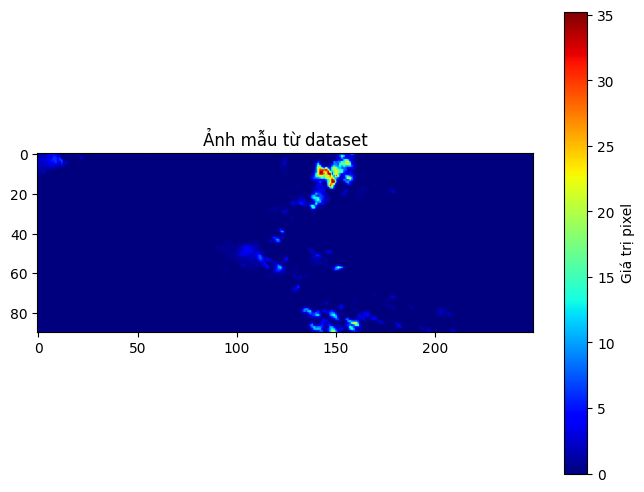

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001100000.tif


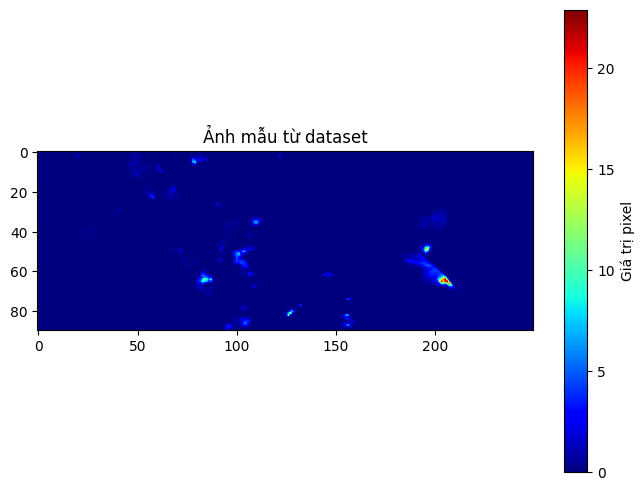

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001160000.tif


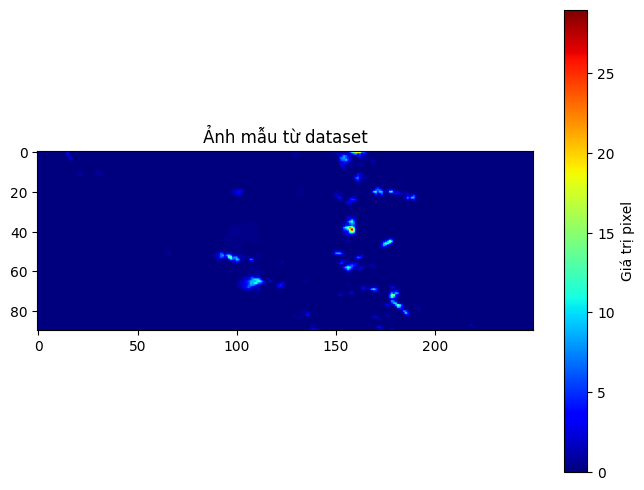

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001000000.tif


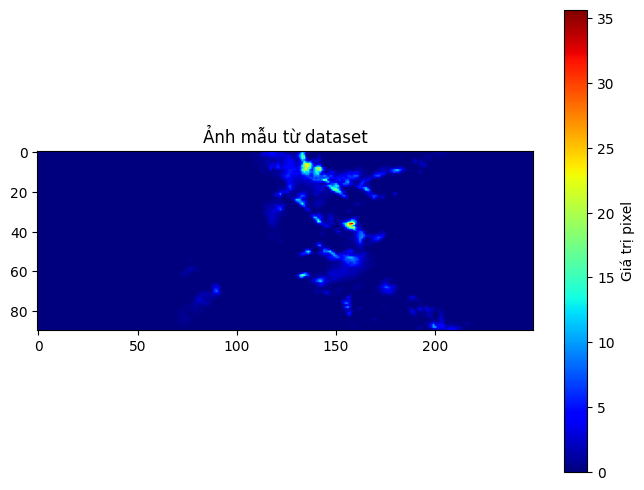

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001180000.tif


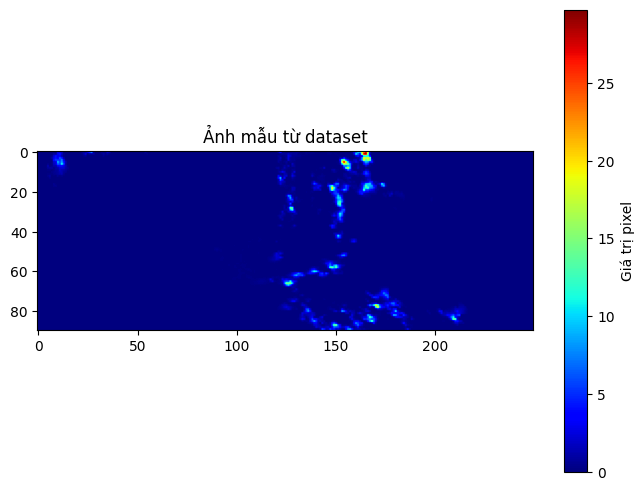

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001210000.tif


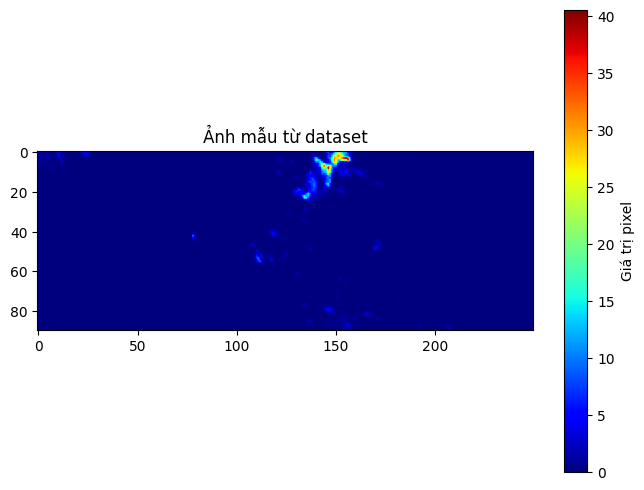

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001220000.tif


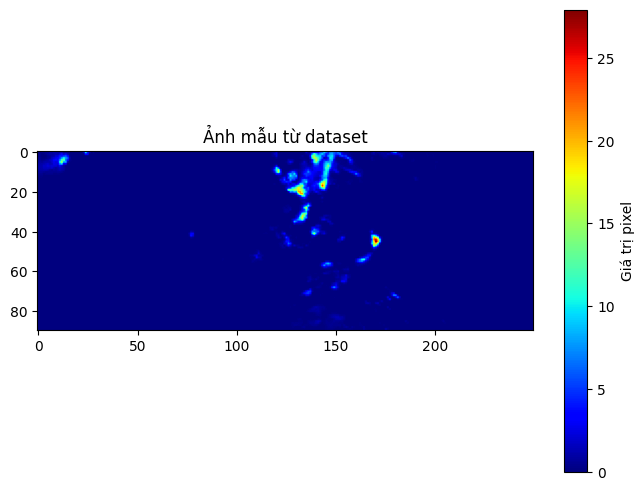

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001150000.tif


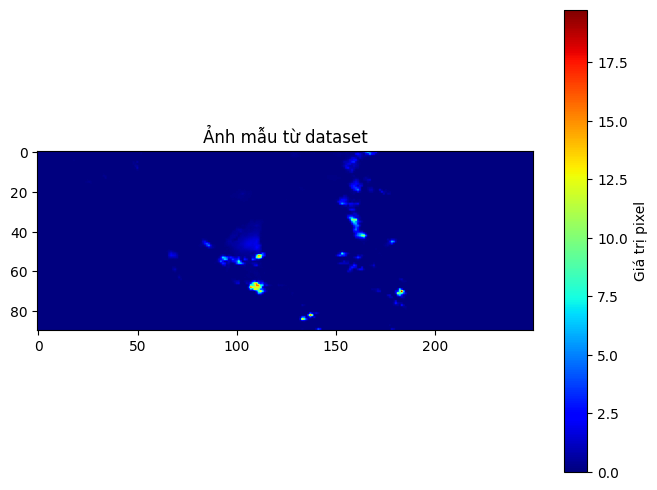

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001020000.tif


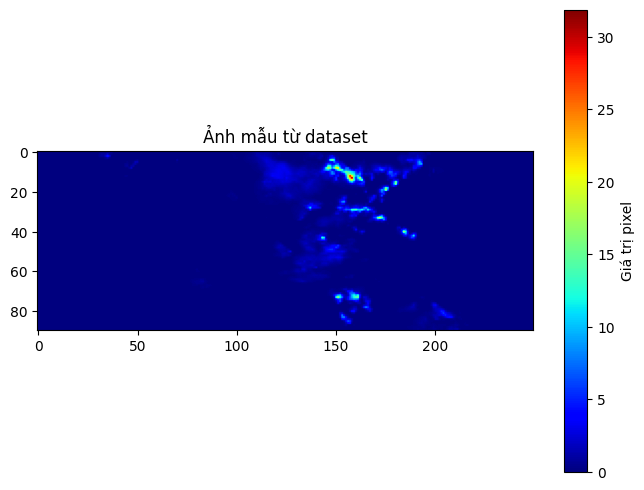

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001230000.tif


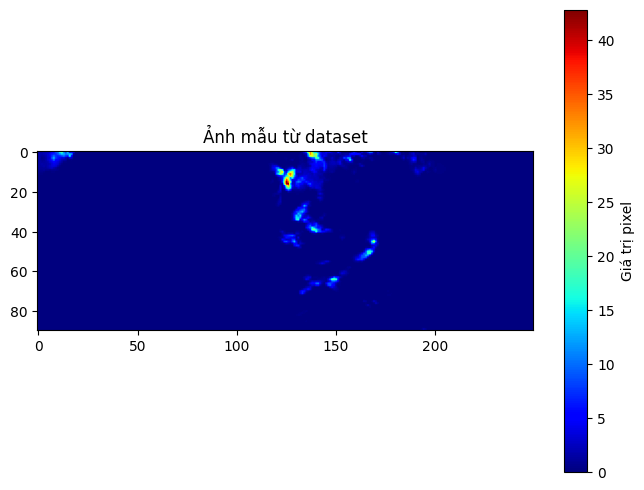

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001130000.tif


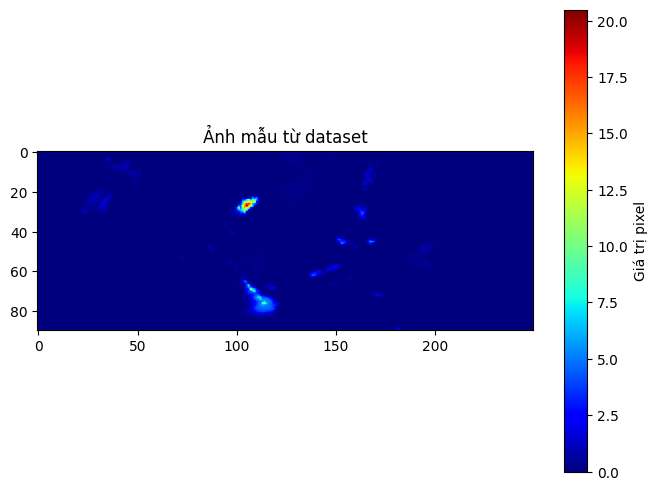

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001010000.tif


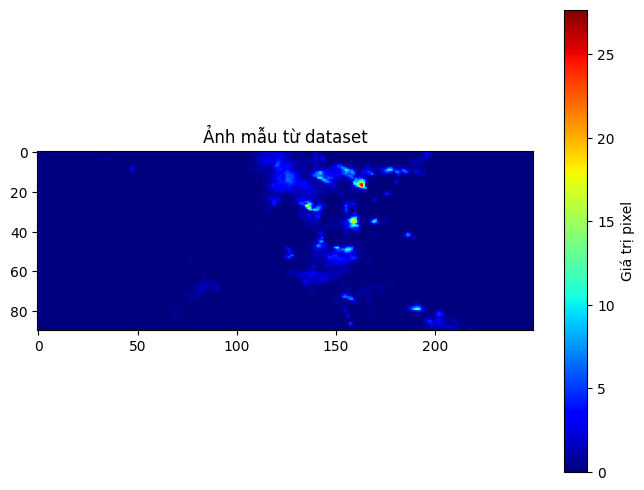

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001050000.tif


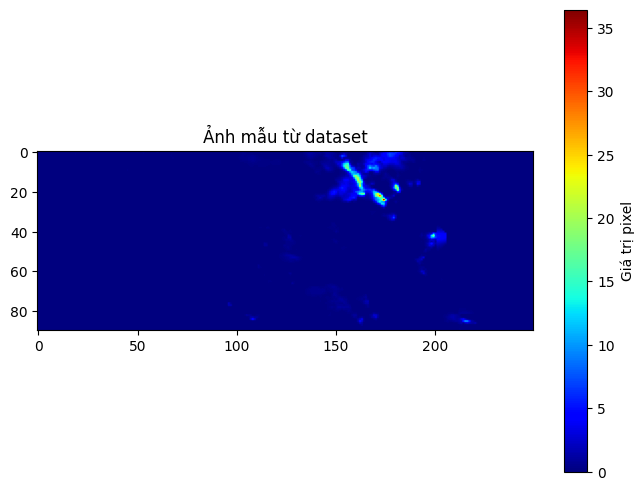

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001170000.tif


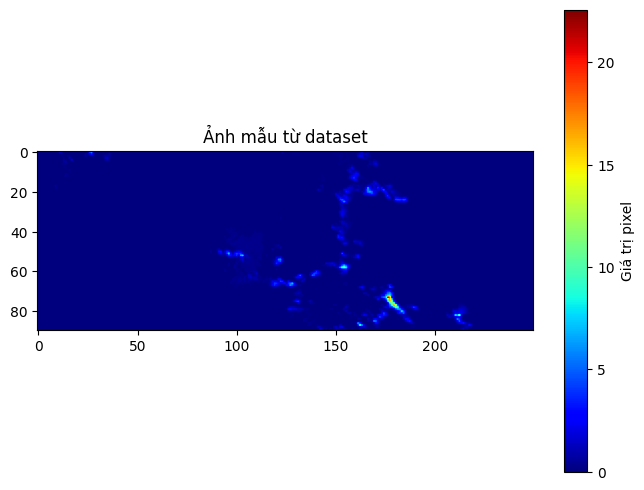

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001120000.tif


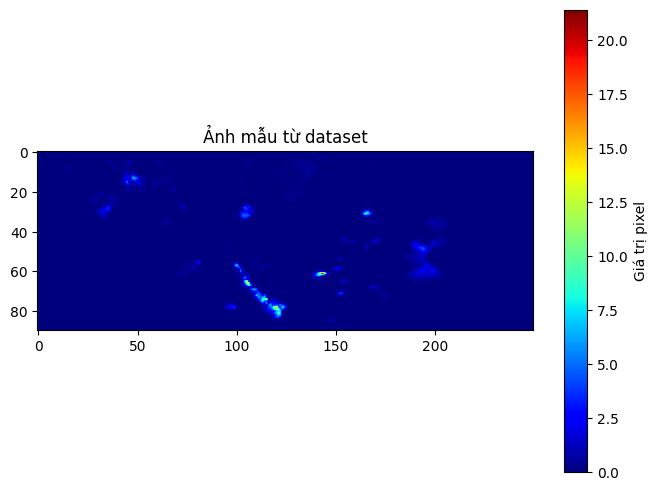

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001070000.tif


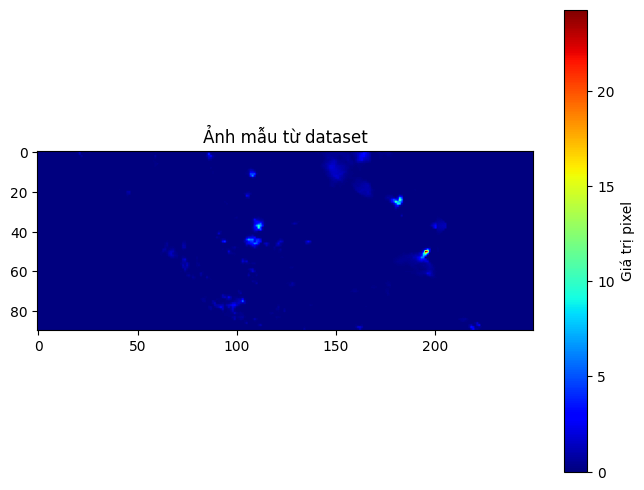

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001090000.tif


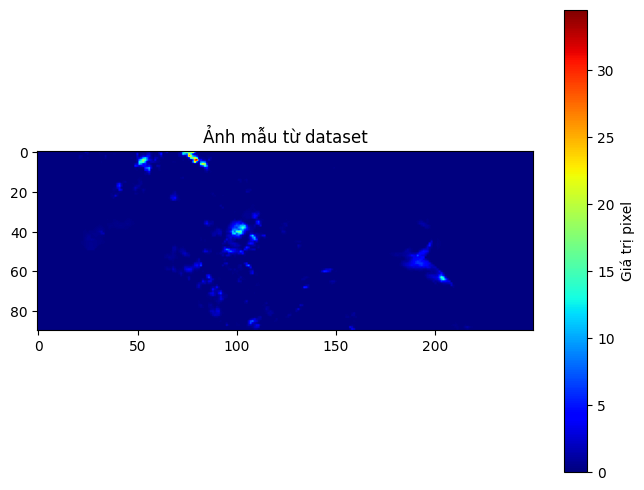

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001140000.tif


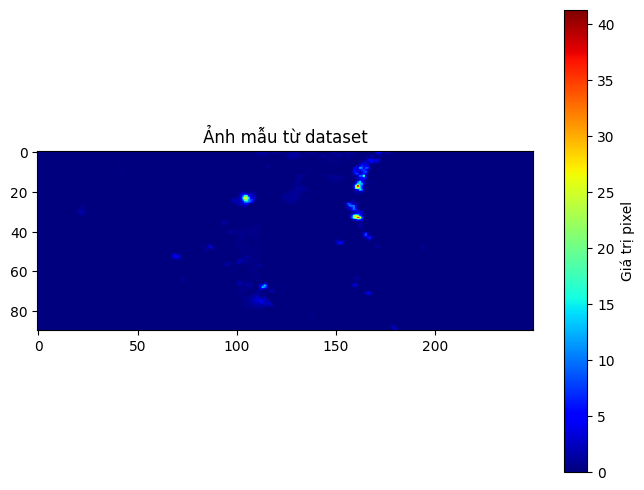

/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/Radar_20201001040000.tif


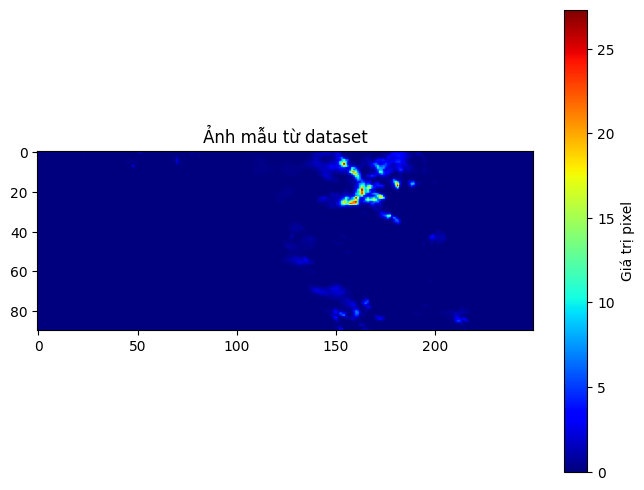

In [16]:
import os

folder_path = "/kaggle/input/data-rain-filled/radar_data (1)/kaggle/working/processed/Radar/2020/10/01/"  # Thay bằng đường dẫn thư mục của bạn

for dirname, _, filenames in os.walk(folder_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        t = dirname + filename
        drawdata(t)